# 全盲预处理与多曝光联合检测（不训练 ASTERIS）

**本次验收限制：**保留的十张背景同帧样本中，64 像素块背景起伏中位数由约 12 DN 上升至 29 DN。
较保守的 64 像素网格尚未证明更优；训练前应进行 32/64 网格的背景与注入源对照。
全部联合检测仍有共有结构警告，`90000005_2` 有 69/80 帧 PSF 回退、80/80 帧透过率回退。

1. 1/f 与背景处理不读取星表/测量表，掩膜只来自探测器质量和图像自动检测。
2. 配准使用图像自动星点；坏像元先排除，再按有效插值权重归一化。
3. 按 Zackay & Ofek I 构建逐曝光 PSF 匹配检测统计量，输出覆盖数、经验显著性、奇偶检验和盲检列表。

参考：[Paper I](https://arxiv.org/abs/1512.06872)、[Paper II](https://arxiv.org/abs/1512.06879)。
PDF 已保存到项目上一级的 `paper`。这里实现的是 Paper I 的高斯 PSF 近似基线，**不是** Paper II 的 proper coadd。
星表只能在检测输出冻结后供人工核验；处理单元不读取星表，末尾提供独立的只读标注展示。

In [1]:
from pathlib import Path
import sys, subprocess, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from IPython.display import display
start=Path.cwd().resolve()
ROOT=next(p for p in (start,*start.parents) if (p/'src/astr_ir').is_dir())
sys.path.insert(0,str(ROOT/'src'))
PROCESSED=ROOT/'data/processed'
OLD=PROCESSED/'comparison_before_blind_v2'
JOINT=PROCESSED/'blind_joint'
sequences=sorted(p.name for p in (PROCESSED/'background').iterdir() if p.is_dir())
print(sequences)

['90000002', '90000003', '90000004', '90000005_1', '90000005_2']


## 1. 运行入口（默认不执行，防止查看 Notebook 时覆盖产品）

完整命令会先在 `comparison_before_blind_v2/{flicker,background}/{sequence}` 各保存首末两张旧科学图，
以 `old_` 开头，再更新原来的 1/f 与背景输出路径。中断可加 `--resume`，不会覆盖旧对比备份。
此流程不修改 raw，不运行网络训练/推理，也不覆盖已有 ASTERIS coadd。

In [2]:
RUN_PREPROCESS=False
RESUME_PREPROCESS=True
RUN_JOINT=False
if RUN_PREPROCESS:
    command=[sys.executable,str(ROOT/'scripts/maintenance/run_pre_asteris.py'),'--workers','2']
    if RESUME_PREPROCESS: command.append('--resume')
    subprocess.run(command,cwd=ROOT,check=True)
if RUN_JOINT:
    subprocess.run([sys.executable,str(ROOT/'scripts/evaluation/run_blind_joint_detection.py')],cwd=ROOT,check=True)

## 2. 全帧状态与背景指标（不能替代真实源完备率）

In [3]:
for stage in ('flicker','background'):
    table=pd.read_csv(PROCESSED/stage/f'{stage}_statistics.csv',dtype={'sequence':str})
    display(table.groupby(['sequence','status']).size().rename('frames').to_frame())
    assert len(table)==400
    assert (table.equation_max_abs_error_float32==0).all()
    assert not table.photometry_gate_active.any()
    metric='relative_reduction' if stage=='flicker' else 'large_scale_reduction'
    display(table.groupby('sequence')[metric].agg(['median','min','max']))

,,frames
sequence,status,
90000002,corrected,80
90000003,corrected,80
90000004,corrected,80
90000005_1,corrected,80
90000005_2,corrected,80


,median,min,max
sequence,,,
90000002,0.579625,0.507243,1.0
90000003,0.578153,0.507700,1.0
90000004,0.573413,0.488078,1.0
90000005_1,0.564665,0.470091,1.0
90000005_2,0.652246,0.488899,1.0


,,frames
sequence,status,
90000002,background_subtracted,80
90000003,background_subtracted,80
90000004,background_subtracted,80
90000005_1,background_subtracted,80
90000005_2,background_subtracted,80


,median,min,max
sequence,,,
90000002,0.839565,0.818889,0.860684
90000003,0.834030,0.794704,0.857704
90000004,0.842012,0.825546,0.861084
90000005_1,0.844989,0.825032,0.860671
90000005_2,0.818345,0.796122,0.846502


## 3. 旧/新同一帧对比（相同色标，显示时去除全局中位数）

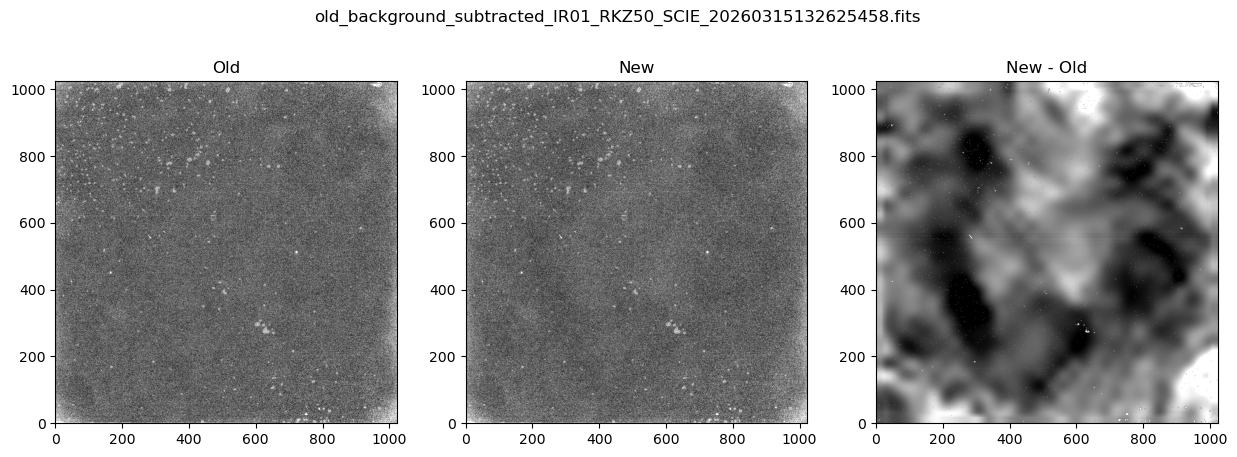

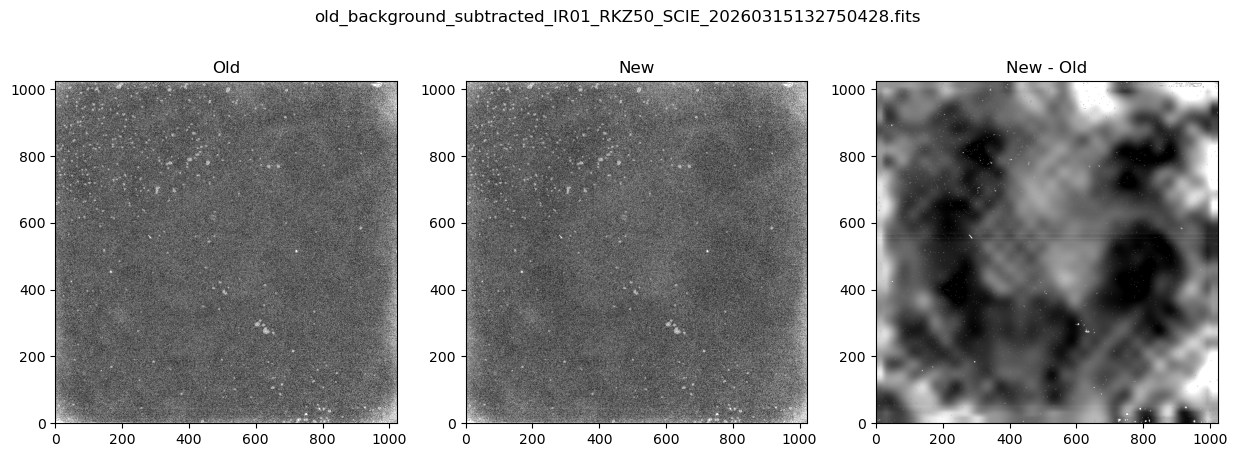

In [4]:
SEQUENCE=sequences[0]
STAGE='background'
old_paths=sorted((OLD/STAGE/SEQUENCE).glob('old_*.fits'))
for old_path in old_paths:
    new_path=PROCESSED/STAGE/SEQUENCE/old_path.name.removeprefix('old_')
    old=fits.getdata(old_path).astype(float)
    new=fits.getdata(new_path).astype(float)
    with fits.open(new_path) as hdul: valid=(hdul['DQ'].data & 1)==0
    old=np.where(valid,old,np.nan); new=np.where(valid,new,np.nan)
    old-=np.nanmedian(old); new-=np.nanmedian(new)
    lo,hi=np.nanpercentile(old,[2,99.5])
    fig,axes=plt.subplots(1,3,figsize=(15,5))
    for ax,data,title in zip(axes,(old,new,new-old),('Old','New','New - Old')):
        bounds=(lo,hi) if title!='New - Old' else tuple(np.nanpercentile(new-old,[2,98]))
        ax.imshow(data,origin='lower',cmap='gray',vmin=bounds[0],vmax=bounds[1]); ax.set_title(title)
    fig.suptitle(old_path.name); plt.show()

## 4. 联合检测结果

`weighted_coadd` 是普通逆方差加权科学图；`joint_score` 是经验归一化的 PSF 检测图，不能当作 DN 图测光。
`joint_flux` 是高斯 PSF 总通量估计；`joint_nominal_score` 保留独立噪声假设下的值。
`odd_even_null` 检查两半数据的差异。检测阈值固定为经验 S/N≥5，不代表已校准的 5σ 误报率。
每个试探位置同时拟合局部常数背景，并计入其方差代价；这是理想已知背景统计量的扩展。
自动星点不足时，PSF sigma 回退到 2.5 像素、相对透过率回退到 1；下表明确列出回退帧数。
CSV 的 (x,y) 为零基；DS9 regions 已转换成一基。坐标基准为各序列首帧，不能直接套旧 ASTERIS 星表标注。

,sequence,frames,detections_ge5,detections_both_halves_ge3,negative_peaks_ge5,empirical_noise_scale,shared_structure_warning,null_robust_std,psf_fallback_frames,transparency_fallback_frames
0,90000002,80,366,364,54,4.109443,True,0.971397,0,11
1,90000003,80,377,376,54,4.112368,True,0.954301,0,0
2,90000004,80,384,383,54,4.236928,True,0.952307,0,0
3,90000005_1,80,375,374,48,4.332559,True,0.955278,0,0
4,90000005_2,80,107,107,23,3.391678,True,0.953372,69,80


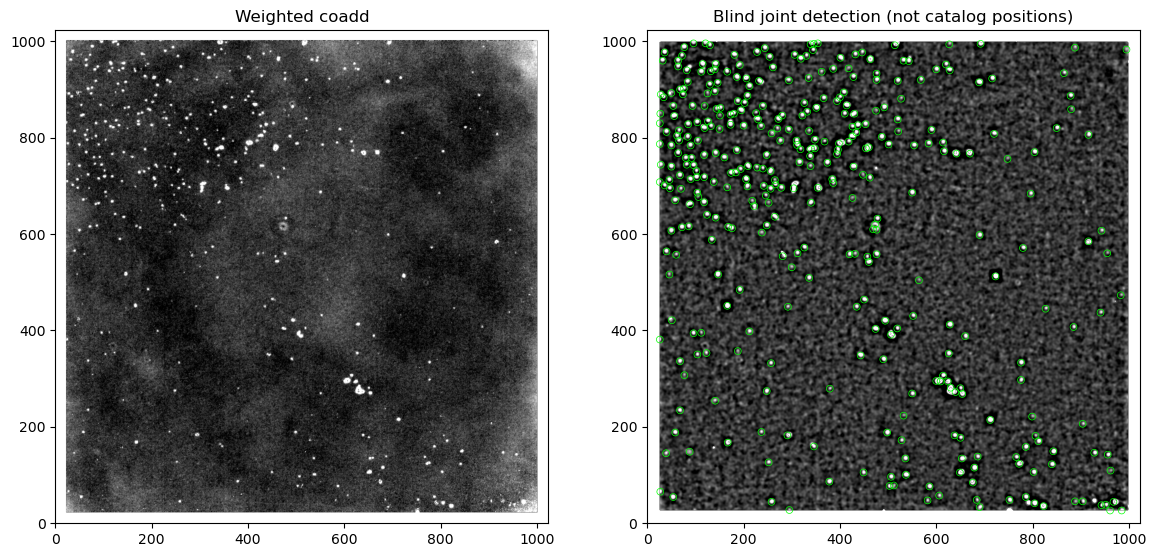

,x,y,snr_empirical,snr_even,snr_odd,flux,coverage,both_halves_ge3
0,723,512,108.687410,105.022922,105.430943,97297.544838,80.0,True
1,166,451,71.724393,69.946453,68.934885,64183.125314,80.0,True
2,804,41,29.565370,28.442613,28.805541,29775.691659,80.0,True
3,823,35,28.940046,27.920038,28.116636,29845.447858,76.0,True
4,712,214,28.934933,27.568618,28.457341,30768.999675,77.0,True
5,692,995,27.774510,27.473621,26.299660,30333.294650,73.0,True
6,689,915,27.538651,27.007089,26.308681,29507.642022,77.0,True
7,649,105,26.603729,25.234000,26.279139,26303.866542,80.0,True
8,679,115,26.583486,25.757519,25.716202,26306.051207,80.0,True
9,463,963,26.555038,26.387576,25.000127,29491.401468,70.0,True


In [5]:
summaries=[json.loads((JOINT/s/'summary.json').read_text()) for s in sequences]
display(pd.DataFrame(summaries)[['sequence','frames','detections_ge5','detections_both_halves_ge3','negative_peaks_ge5','empirical_noise_scale','shared_structure_warning','null_robust_std','psf_fallback_frames','transparency_fallback_frames']])
sources=pd.read_csv(JOINT/SEQUENCE/'blind_sources.csv')
coadd=fits.getdata(JOINT/SEQUENCE/f'weighted_coadd_{SEQUENCE}.fits')
score=fits.getdata(JOINT/SEQUENCE/f'joint_score_{SEQUENCE}.fits')
fig,axes=plt.subplots(1,2,figsize=(14,7))
lo,hi=np.nanpercentile(coadd,[2,99.5])
axes[0].imshow(coadd,origin='lower',cmap='gray',vmin=lo,vmax=hi)
axes[1].imshow(score,origin='lower',cmap='gray',vmin=-2,vmax=8)
axes[1].scatter(sources.x,sources.y,s=24,facecolors='none',edgecolors='lime',linewidths=.5)
axes[0].set_title('Weighted coadd'); axes[1].set_title('Blind joint detection (not catalog positions)')
plt.show()
display(sources.head(20))

## 后续 ASTERIS 比较的边界

本次未训练，旧模型和 coadd 仍对应旧预处理。未来比较模型时必须用同一版上游输入、同一冻结测试帧与曝光数，
重新 prepare 盲配准 manifest；不能把当前 80 帧联合检测与旧 16 帧测试 coadd 直接比较并宣称模型提升。

## 5. 真实星表弱源位置可视化（仅展示，不参与处理）

复用已保存的 2MASS / Gaia 匹配信息及 `weak_sources.csv`，仅覆盖已标定的
`90000002`、`90000003`，每个序列固定 12 个 W01–W12。其余序列没有已核验的星表解，不能套用这些位置。

新共加图使用首曝光坐标，旧 ASTERIS 图使用历史配准坐标。
下面先以**图像自动星点**估计旧参考图到新共加图的平移（至少 6 个匹配星、每轴 RMS≤0.75 像素），
再整体转换已有星表位置；不在弱源附近寻找峰值、不重新筛选弱源，不回写 FITS、星表、检测列表或模型。

输出 `figures/catalog_validation_output/{sequence}/`：
4 张全幅标注图（新 weighted_coadd、joint_score、旧 ASTERIS160/400）、3 页局部放大图、
精确绘图坐标 CSV 和校验/来源 JSON。青色圆圈是星表预测位置，橙色表示该位置像元无效，**不是检出标志**。
坐标为零基，显示采用 origin=lower；圆圈半径只是视觉标记，不是天体测量误差。

**解释边界：**这是固定的历史弱源样本（原先按旧输入的峰值 SNR / K 等条件选取），不是完备星表或无偏检测测试。
当前共加/检测图使用 80 帧，旧论文版共加使用 16 帧且预处理不同；各图/局部使用独立显示拉伸，
不能通过亮暗或平滑程度直接宣称模型性能提高。已有 WCS 误差与新平移残差会分别记录。

本段可独立运行，只读取本地已存在的数据，不联网、不训练、不重新执行上游流程。
重复运行仅更新本段在 figures 中生成的图和说明表。

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import display, Image as DisplayImage

start = Path.cwd().resolve()
CATALOG_PROJECT_ROOT = next(p for p in (start, *start.parents) if (p / "src" / "astr_ir").is_dir())
sys.path.insert(0, str(CATALOG_PROJECT_ROOT / "src"))
from astr_ir.evaluation.catalog_visualization import export_catalog_validation

CATALOG_SEQUENCES = ("90000002", "90000003")  # 目前有已核验星表的两个序列
CATALOG_FIGURE_ROOT = CATALOG_PROJECT_ROOT / "figures" / "catalog_validation_output"
catalog_visualizations = export_catalog_validation(
    CATALOG_PROJECT_ROOT, sequences=CATALOG_SEQUENCES,
    output_dir=CATALOG_FIGURE_ROOT, dpi=160, cutout_half_size=24,
)
display(pd.DataFrame(catalog_visualizations)[[
    "sequence", "weak_sources", "matched_stars", "transfer_rms_pix", "original_wcs_rms_pix"
]])
print("标注图和逐源坐标已保存至:", CATALOG_FIGURE_ROOT)
for result in catalog_visualizations:
    print(result["sequence"], "完整图:", result["weighted_coadd"])
    print("局部放大图:", *result["cutouts"], sep="\n")

,sequence,weak_sources,matched_stars,transfer_rms_pix,original_wcs_rms_pix
0,90000002,12,24,0.243799,0.897082
1,90000003,12,34,0.157395,0.200961


标注图和逐源坐标已保存至: D:\Astr_IR\code\figures\catalog_validation_output
90000002 完整图: D:\Astr_IR\code\figures\catalog_validation_output\90000002\90000002_weighted_coadd_catalog_overlay.png
局部放大图:
D:\Astr_IR\code\figures\catalog_validation_output\90000002\90000002_weak_source_cutouts_01.png
D:\Astr_IR\code\figures\catalog_validation_output\90000002\90000002_weak_source_cutouts_02.png
D:\Astr_IR\code\figures\catalog_validation_output\90000002\90000002_weak_source_cutouts_03.png
90000003 完整图: D:\Astr_IR\code\figures\catalog_validation_output\90000003\90000003_weighted_coadd_catalog_overlay.png
局部放大图:
D:\Astr_IR\code\figures\catalog_validation_output\90000003\90000003_weak_source_cutouts_01.png
D:\Astr_IR\code\figures\catalog_validation_output\90000003\90000003_weak_source_cutouts_02.png
D:\Astr_IR\code\figures\catalog_validation_output\90000003\90000003_weak_source_cutouts_03.png


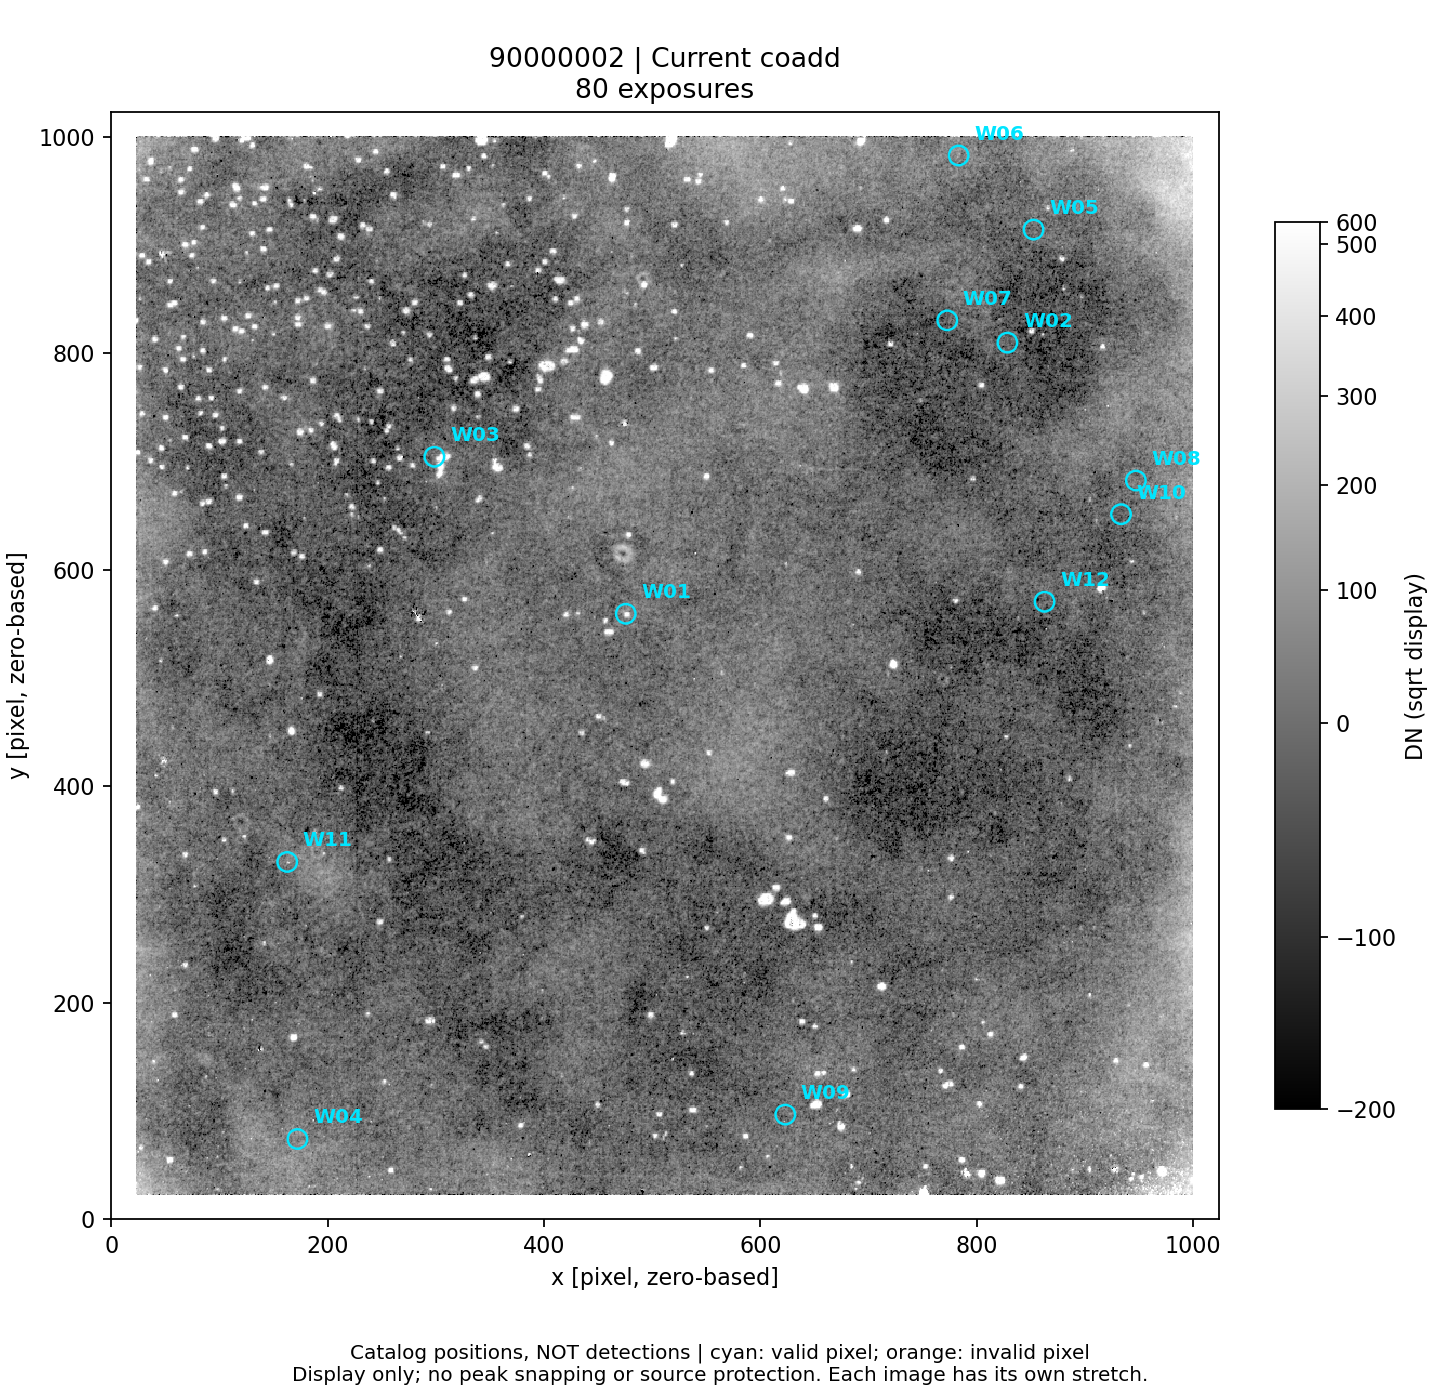

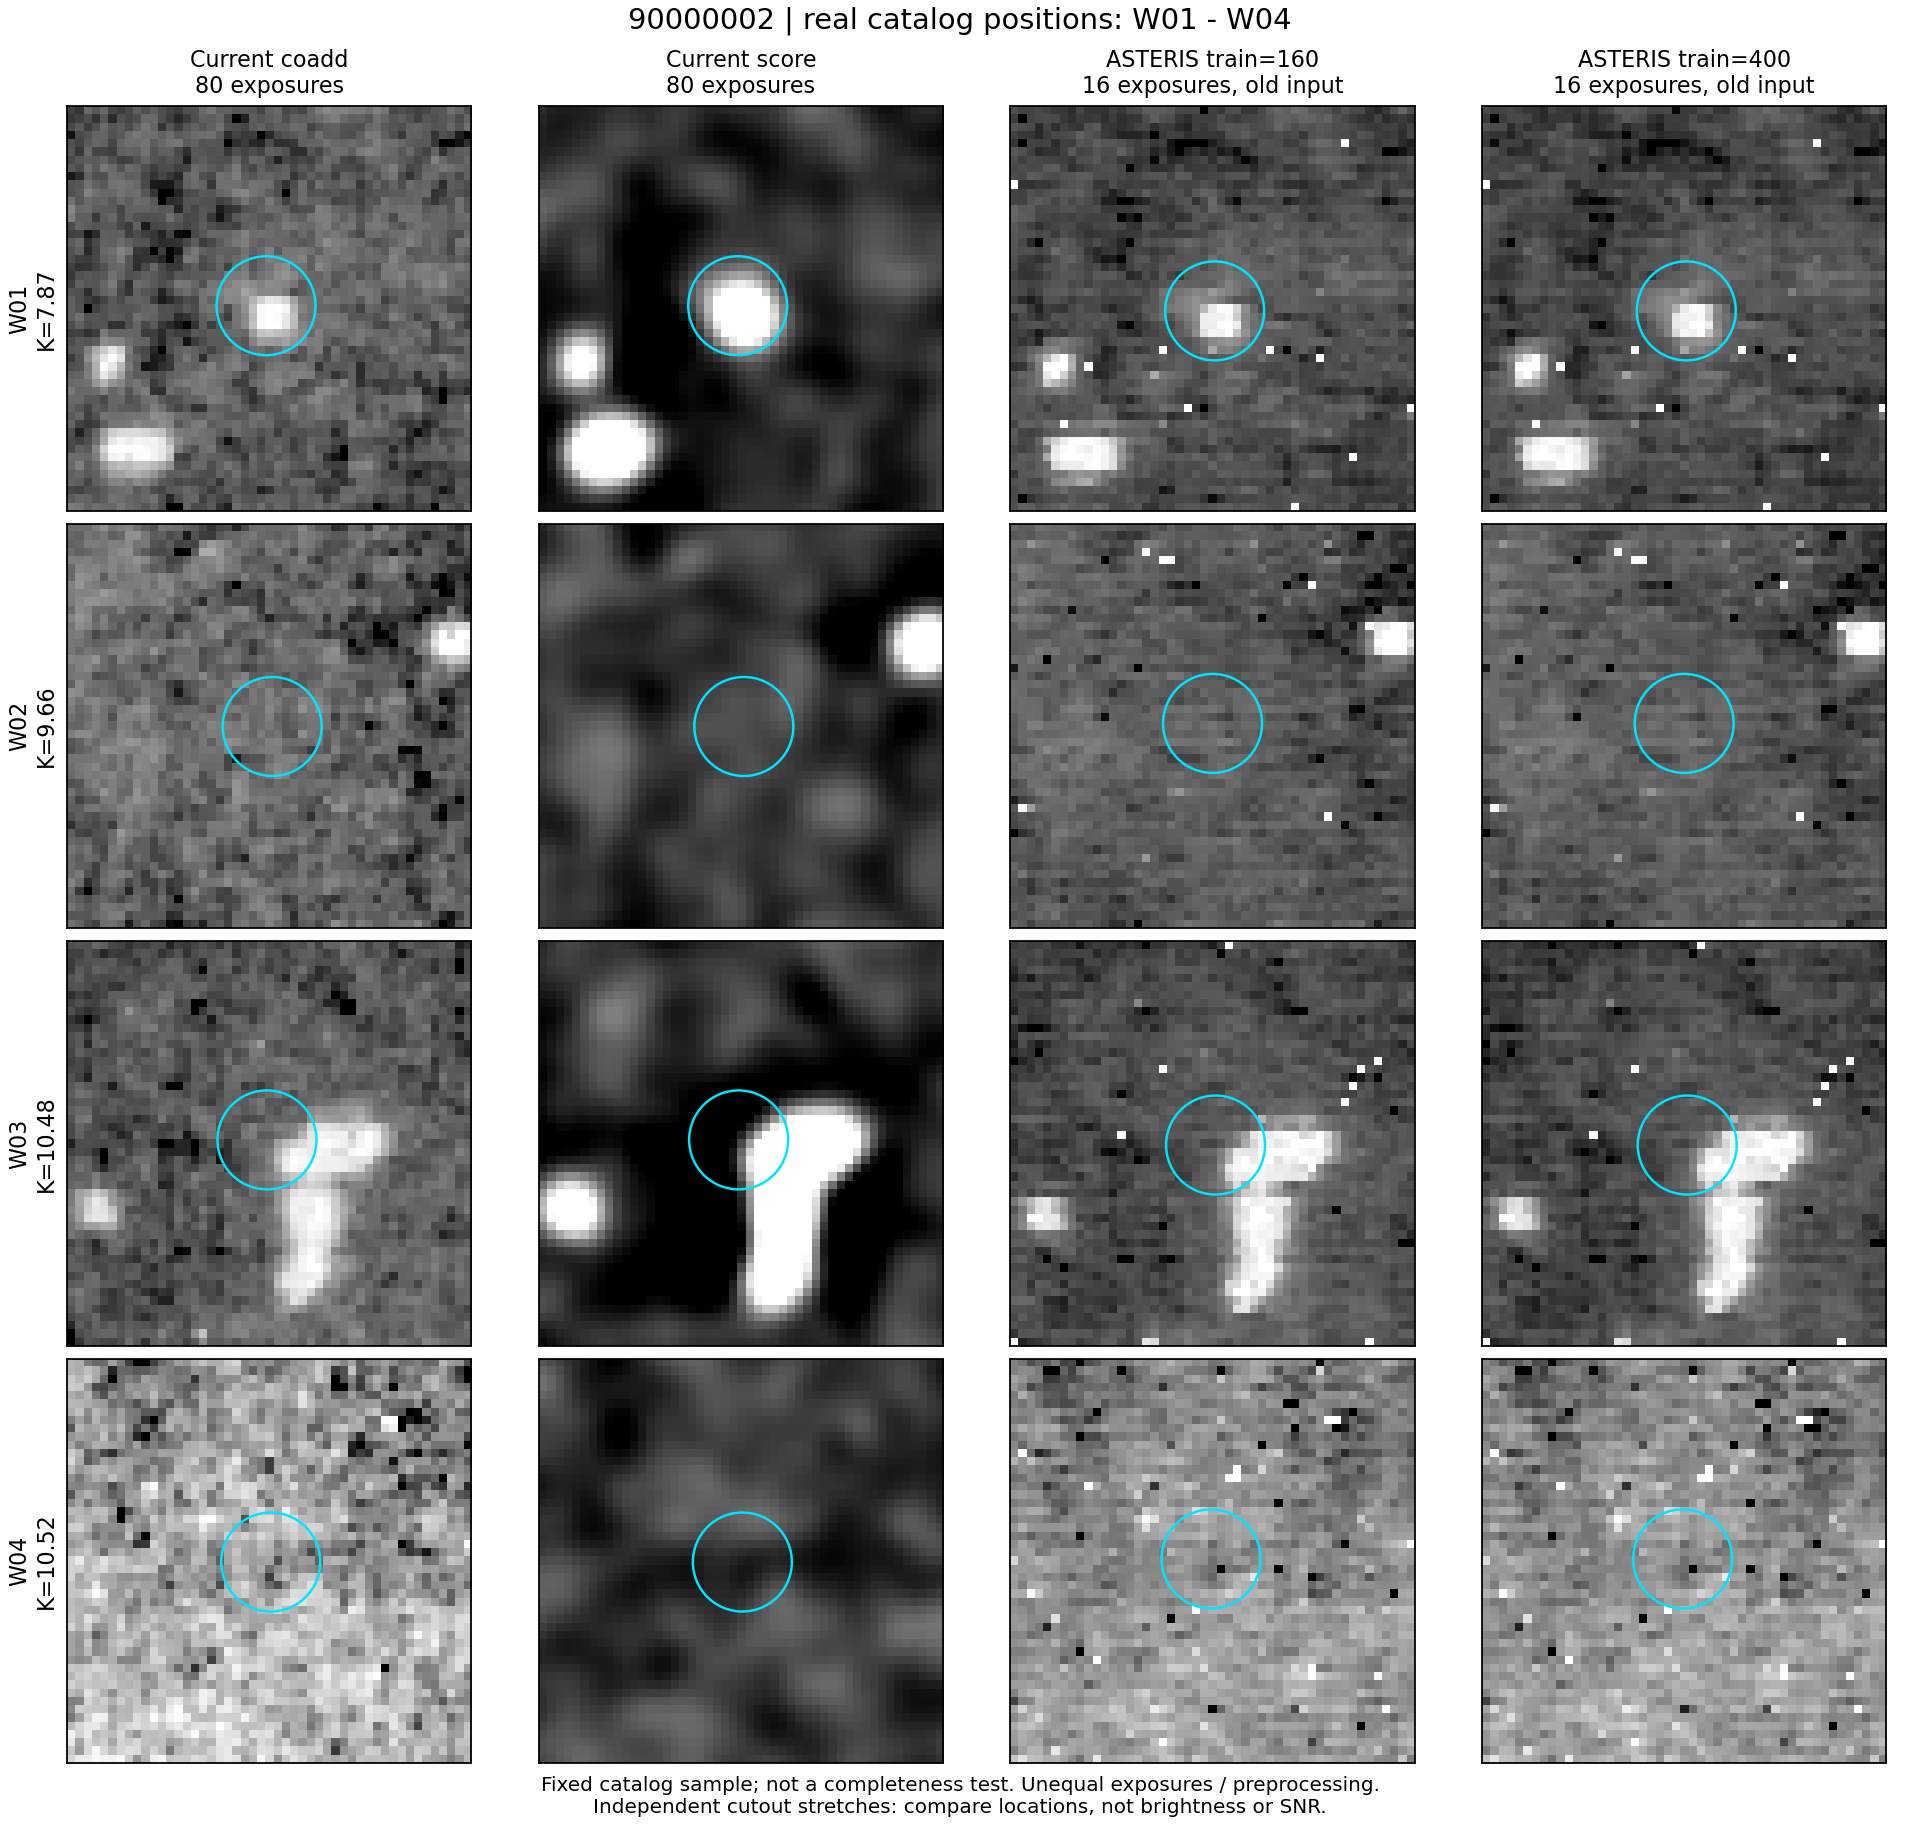

In [2]:
# 可切换到 "90000003"；文件夹中还包含 joint_score 和两个 ASTERIS 结果。
SHOW_SEQUENCE = "90000002"
selected = next(item for item in catalog_visualizations if item["sequence"] == SHOW_SEQUENCE)
display(DisplayImage(filename=selected["weighted_coadd"], width=1000))
display(DisplayImage(filename=selected["cutouts"][0], width=1100))